In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
%pip install matplotlib seaborn scikit-learn pandas numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 883.3 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.5 MB 790.9 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.5 MB 790.9 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.5 MB 742.8 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.5 MB 812.5 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/9.5 MB 812.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 5)

Column Names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:

df = df.drop(columns=["Unnamed: 0"])
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [9]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (200, 4)

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate Rows: 0


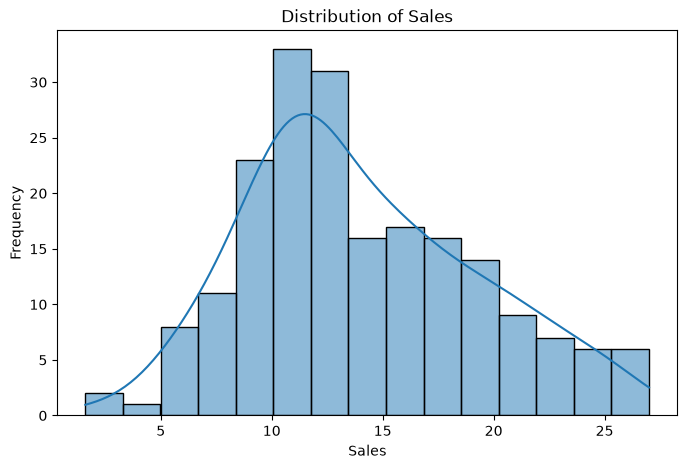

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Sales"], bins=15, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

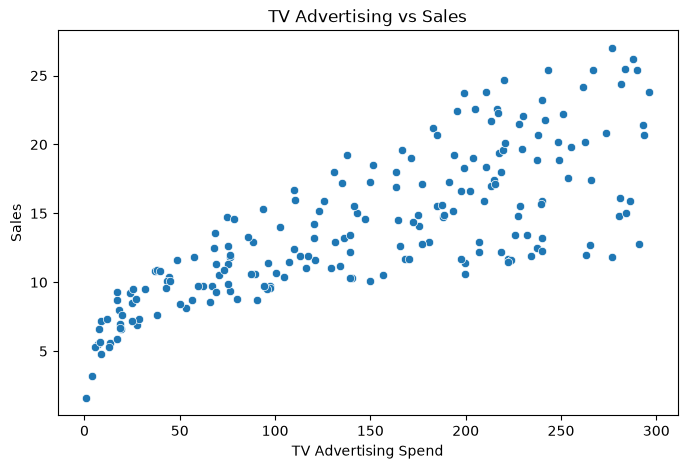

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

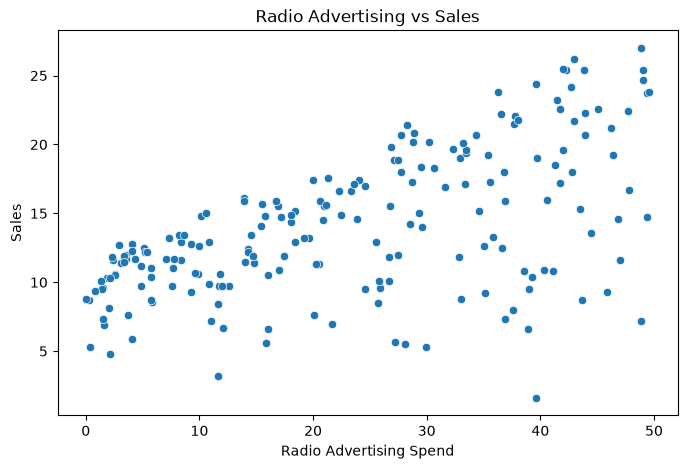

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

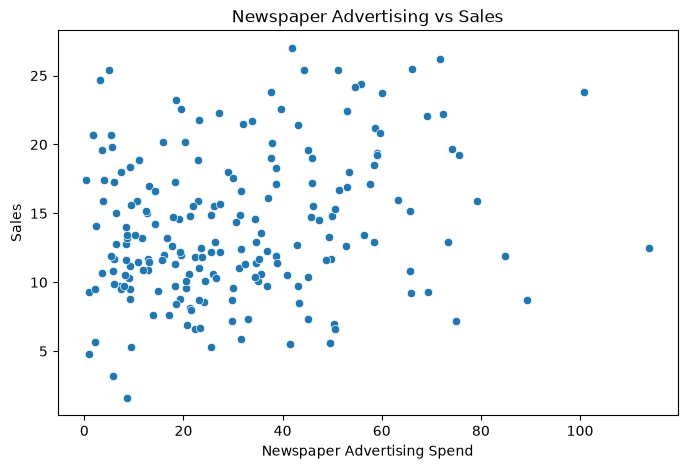

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

In [14]:

correlation_matrix = df.corr()

correlation_matrix

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


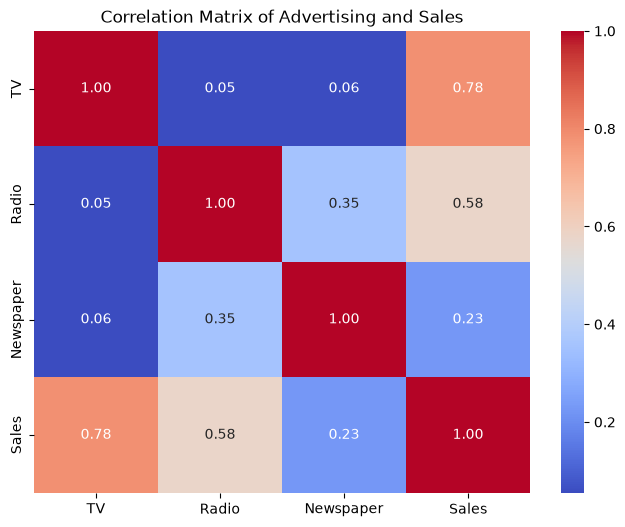

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Advertising and Sales")
plt.show()

In [16]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['TV', 'Radio', 'Newspaper']
Target: Sales


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (160, 3)
Testing features: (40, 3)


In [19]:

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [21]:

y_pred = model.predict(X_test)
y_pred[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

In [22]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [23]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Performance")
print("-----------------------------------")
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))
print("R²   :", round(r2, 4))

Linear Regression Model Performance
-----------------------------------
MAE  : 1.4608
RMSE : 1.7816
R²   : 0.8994


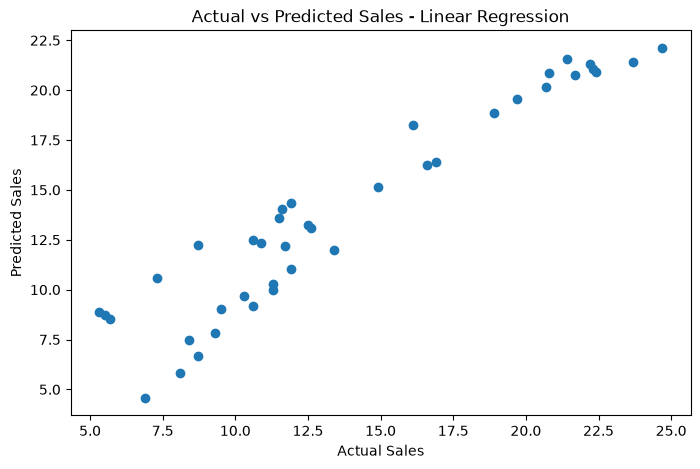

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Linear Regression")

plt.show()

In [25]:
# Get the coefficients of the Linear Regression model

coefficients = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Advertising Channel,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


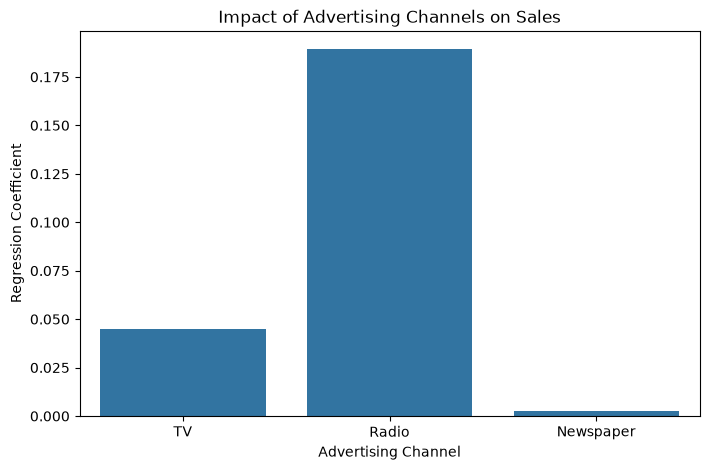

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x="Advertising Channel",
    y="Coefficient"
)

plt.title("Impact of Advertising Channels on Sales")
plt.xlabel("Advertising Channel")
plt.ylabel("Regression Coefficient")

plt.show()

In [27]:
# Future advertising budget
future_advertising = pd.DataFrame({
    "TV": [200],
    "Radio": [30],
    "Newspaper": [20]
})

future_advertising

,TV,Radio,Newspaper
0,200,30,20


In [28]:
# Predict future sales
future_sales = model.predict(future_advertising)

print("Predicted Future Sales:", round(future_sales[0], 2))

Predicted Future Sales: 17.66
